# Análisis §5.4 — Medio estratificado de dos capas (PLIN, haz 2500 μm)

Sistema: capa TOP finita ($r_{\rm top}=35$ nm, $\ell^*_{\rm top}$ grande → cono **estrecho**, difusión transversal rápida) sobre fondo BOT semi-infinito ($r_{\rm bot}=75$ nm, $\ell^*_{\rm bot}$ pequeño → cono **ancho**). Barrido del espesor $d = m\,\ell^*_{\rm top}$, $m\in[0.1,10]$, 5 réplicas, grillas angular y temporal **compartidas** entre espesores.

Mapa de bloques:

| Bloque | Física que prueba | Archivo |
|---|---|---|
| Gate    | límites $m\to0$ (≈ BOT homogéneo) y $m\to\infty$ (≈ TOP homogéneo) vs §5.1 | `gate_limites_capas.pdf` |
| **F13** | familia estacionaria $\gamma(\theta;d)$: perfil de **dos escalas** | `F13_familia_espesor.pdf` |
| **F14** | observables vs espesor: $\theta_{\rm FWHM}(d)$, $E(0)(d)$, $\rho(d)$ | `F14_observables_vs_d.pdf` |
| **F15** | modelo: fallo del cono único (no hay medio efectivo) vs superposición de dos conos → peso $w(d)$ | `F15_modelo_dos_conos.pdf` |
| **F16** | time-resolved: $\Delta\theta(t)$ por espesor, quiebre en $t^*(d)$ | `F16_ancho_vs_t.pdf` |
| **F17** | escalamiento difusivo $t^* \propto d^2$ | `F17_tstar_vs_d2.pdf` |
| Tabla   | $(d, m, {\rm FWHM}, E_0, \rho, w, t^*)$ | `tabla_capas.csv/.tex` |

Narrativa (contraste con §5.3): la **mezcla** es un medio efectivo exacto donde la superposición naive falla (brecha de Jensen); el medio **estratificado** es lo opuesto — no admite medio efectivo (perfil de dos escalas) pero la superposición de dos conos sí lo describe, porque las especies están segregadas espacialmente. El time-resolved añade lo que el estacionario no tiene: la profundidad de la interfaz vía $t^*\propto d^2$.


In [4]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

In [5]:
from utils.loaders import load_sweep
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL

import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass, field


@dataclass
class GroupedZ:
    z: float                    # espesor de TOP [um]
    mult: float                 # z / l*_top
    replicas_keys: list = field(default_factory=list)
    name: str = ""


In [6]:
# ===========================================================================
# Carga y agrupación por espesor
# ===========================================================================
save_path = "/Users/niaggar/Results"
folder = "study_two_layers__PLIN__beam2500"

N_MEDIUM = 1.33
WAVELENGTH = 0.514
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
N_TIME_BINS = 100               # TIME_NBINS del script (bin 0 = integrado)

sweep_data = load_sweep(folder, base_path=Path(save_path))
print(f"Loaded {len(sweep_data.keys())} datasets")

_by_z = {}
for key in sweep_data.keys():
    m = re.search(r"z_interface_([0-9.]+)__rep(\d+)", key)
    if not m:
        print(f"[skip] {key}")
        continue
    _by_z.setdefault(float(m.group(1)), []).append(key)

Z_VALUES = np.array(sorted(_by_z))

# parámetros compartidos (réplica 0 del primer espesor)
_p0 = sweep_data[sorted(_by_z[Z_VALUES[0]])[0]].params_flat
L_TOP = float(_p0["l_star_top"])
L_BOT = float(_p0["l_star_bot"])
TAU_TOP_FS = L_TOP * N_MEDIUM / 0.299792458        # tau*_top [fs]
GRID = _p0.get("time_grid", None)

groups = [GroupedZ(z=z, mult=z / L_TOP, replicas_keys=sorted(_by_z[z]),
                   name=rf"$d={z/L_TOP:.1f}\,\ell^*_{{\rm top}}$")
          for z in Z_VALUES]

print(f"l*_top = {L_TOP:.2f} um   l*_bot = {L_BOT:.2f} um   "
      f"tau*_top = {TAU_TOP_FS:.1f} fs")
print("espesores [z um | mult | n réplicas]:")
for g in groups:
    print(f"  {g.z:8.2f} | {g.mult:5.2f} | {len(g.replicas_keys)}")

# controles de extremo dentro del propio barrido (misma grilla):
G_BOTLIKE = groups[0]      # m mínimo  -> se comporta ~ BOT homogéneo
G_TOPLIKE = groups[-1]     # m máximo  -> se comporta ~ TOP homogéneo


Loaded 50 datasets
l*_top = 117.94 um   l*_bot = 23.16 um   tau*_top = 523.2 fs
espesores [z um | mult | n réplicas]:
     11.79 |  0.10 | 5
     23.59 |  0.20 | 5
     58.97 |  0.50 | 5
    117.94 |  1.00 | 5
    176.91 |  1.50 | 5
    235.88 |  2.00 | 5
    353.82 |  3.00 | 5
    589.70 |  5.00 | 5
    825.58 |  7.00 | 5
   1179.40 | 10.00 | 5


In [7]:
# ===========================================================================
# Utilidades: stitching, baseline, perfiles por réplica y suma de réplicas
#   (la suma a nivel de intensidades es el estimador de alto S/N que
#    necesita el time-resolved: 5 x 300k fotones por bin temporal)
# ===========================================================================
eps = 1e-30

def load_stitched(k_, lstar, th1, g1, th2, g2, key, warn=0.05):
    theta_1 = th1[-1]
    lo = 0.9 * theta_1
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > warn:
            print(f"[stitch WARN] {key}: max solape {np.max(resid):.3f}")
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    return theta, k_ * lstar * theta, g


def tail_baseline(q, y, q_min=25.0, n_min=5, frac=0.85):
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]
        return np.median(y[idx])
    return np.median(y[m])


def _profiles_raw(key, phi_index, channel, time_index):
    sw = sweep_data[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                      time_index=time_index, reduce=phi_cut(phi_index))
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                      time_index=time_index, reduce=phi_cut(phi_index))
    return p1, p2


def intensity_sum(keys, phi_index, channel, time_index=0):
    """Suma C y B sobre réplicas (mismo N_PHOTONS -> suma == promedio)."""
    Isum1 = Isum2 = Bsum1 = Bsum2 = None
    th1 = th2 = None
    for key in keys:
        p1, p2 = _profiles_raw(key, phi_index, channel, time_index)
        c1 = np.asarray(p1.coherent[channel], float)
        c2 = np.asarray(p2.coherent[channel], float)
        b1 = np.asarray(p1.incoherent[channel], float)
        b2 = np.asarray(p2.incoherent[channel], float)
        if Isum1 is None:
            Isum1, Isum2 = np.zeros_like(c1), np.zeros_like(c2)
            Bsum1, Bsum2 = np.zeros_like(b1), np.zeros_like(b2)
            th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
        Isum1 += c1; Isum2 += c2; Bsum1 += b1; Bsum2 += b2
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([Isum1, Isum2[keep2]])
    B = np.concatenate([Bsum1, Bsum2[keep2]])
    return theta, I, B


def profile_mean(grouped, phi_index=0, channel="co", time_index=0):
    """Realce de alto S/N: cociente de intensidades sumadas; baseline -> 1.
    q auxiliar anclado a l*_bot (solo para máscaras de cola)."""
    theta, I, B = intensity_sum(grouped.replicas_keys, phi_index, channel, time_index)
    E = (I + eps) / (B + eps)
    q_anchor = k * L_BOT * theta
    return theta, E - tail_baseline(q_anchor, E) + 1.0


def profile_one(key, phi_index=0, channel="co", time_index=0):
    """Realce de UNA réplica (para barras de error de observables)."""
    p1, p2 = _profiles_raw(key, phi_index, channel, time_index)
    E1 = (np.asarray(p1.coherent[channel]) + eps) / (np.asarray(p1.incoherent[channel]) + eps)
    E2 = (np.asarray(p2.coherent[channel]) + eps) / (np.asarray(p2.incoherent[channel]) + eps)
    theta, q_anchor, E = load_stitched(k, L_BOT, np.asarray(p1.theta), E1,
                                       np.asarray(p2.theta), E2, key)
    return theta, E - tail_baseline(q_anchor, E) + 1.0


# --- observables sobre (theta, E) ---
def peak_height(E, n=3):
    return float(np.median(E[:n]))


def fwhm_theta(theta, E, n=3, baseline=1.0):
    """FWHM [rad] por cruce a media altura (interpolación lineal)."""
    E0 = peak_height(E, n)
    half = baseline + 0.5 * (E0 - baseline)
    below = np.where(E < half)[0]
    if len(below) == 0 or below[0] == 0:
        return np.nan
    i = int(below[0])
    th_half = theta[i-1] + (half - E[i-1]) * (theta[i] - theta[i-1]) / (E[i] - E[i-1])
    return 2.0 * th_half


def estimate_noise(E, n_tail=150):
    tail = np.asarray(E[-n_tail:], float)
    kern = np.ones(15) / 15.0
    smooth = np.convolve(tail, kern, mode="same")
    return float(np.std(tail[10:-10] - smooth[10:-10]))


def metric_over_replicas(grouped, phi_index=0, channel="co", time_index=0):
    """(E0, sE0, FWHM[mrad], sFWHM) con error estándar sobre réplicas."""
    E0s, fws = [], []
    for key in grouped.replicas_keys:
        theta, E = profile_one(key, phi_index, channel, time_index)
        E0s.append(peak_height(E))
        fws.append(fwhm_theta(theta, E) * 1e3)
    E0s, fws, n = np.asarray(E0s), np.asarray(fws), len(E0s)
    return (E0s.mean(), E0s.std(ddof=1) / np.sqrt(n),
            np.nanmean(fws), np.nanstd(fws, ddof=1) / np.sqrt(n))


# --- centros de los bins temporales ---
def time_centers_fs(grid, n_bins):
    """Busca en el dict del grid un array de centros (n) o bordes (n+1);
    si no hay, reconstruye bordes geométricos dt..t_max (imprime WARN)."""
    if isinstance(grid, dict):
        arrays = {}
        for kk, vv in grid.items():
            try:
                a = np.asarray(vv, float)
            except Exception:
                continue
            if a.ndim == 1 and len(a) in (n_bins, n_bins + 1):
                arrays[kk] = a
        for kk, a in arrays.items():
            if len(a) == n_bins + 1:
                print(f"[time grid] usando bordes '{kk}'")
                return np.sqrt(a[:-1] * a[1:])
        for kk, a in arrays.items():
            print(f"[time grid] usando centros '{kk}'")
            return a
    dt = float(grid["dt_fs"]) if isinstance(grid, dict) and "dt_fs" in grid else 1.0
    tmax = float(grid["t_max_fs"]) if isinstance(grid, dict) and "t_max_fs" in grid else n_bins
    print("[time grid WARN] sin arrays en params: reconstruyendo bordes "
          "geométricos dt..t_max — verifica contra utils.time.build_time_grid")
    edges = np.geomspace(dt, tmax, n_bins + 1)
    return np.sqrt(edges[:-1] * edges[1:])

T_FS = time_centers_fs(GRID, N_TIME_BINS)
print(f"bins temporales: {len(T_FS)}   t in [{T_FS[0]:.1f}, {T_FS[-1]:.0f}] fs "
      f"= [{T_FS[0]/TAU_TOP_FS:.3f}, {T_FS[-1]/TAU_TOP_FS:.1f}] tau*_top")


[time grid WARN] sin arrays en params: reconstruyendo bordes geométricos dt..t_max — verifica contra utils.time.build_time_grid
bins temporales: 100   t in [1.0, 98] fs = [0.002, 0.2] tau*_top


## Gate de límites

Los extremos del barrido deben degenerar en los medios homogéneos de §5.1:
- $m=0.1$ (TOP casi transparente: $0.1\,\ell^*_{\rm top}\sim 0.1\,\ell_s^{\rm top}$) ≈ **BOT homogéneo** ($r=75$ nm).
- $m=10$ (interfaz fuera del alcance difusivo, $M_{\rm top}<\tfrac32 m^2$) ≈ **TOP homogéneo** ($r=35$ nm).

Las grillas de §5.1 difieren (ancla propia por radio) → se interpola la referencia sobre la grilla del barrido. Se reporta $\chi^2$/bin y RMS en la ventana del cono.


[gate m=0.1 vs radius_0.075] chi2/bin = 9798.53   RMS = 2.64e-01   (theta <= 8.0 mrad, n=5)
[gate m=10.0 vs radius_0.035] chi2/bin = 46.66   RMS = 2.48e-02   (theta <= 2.0 mrad, n=5)


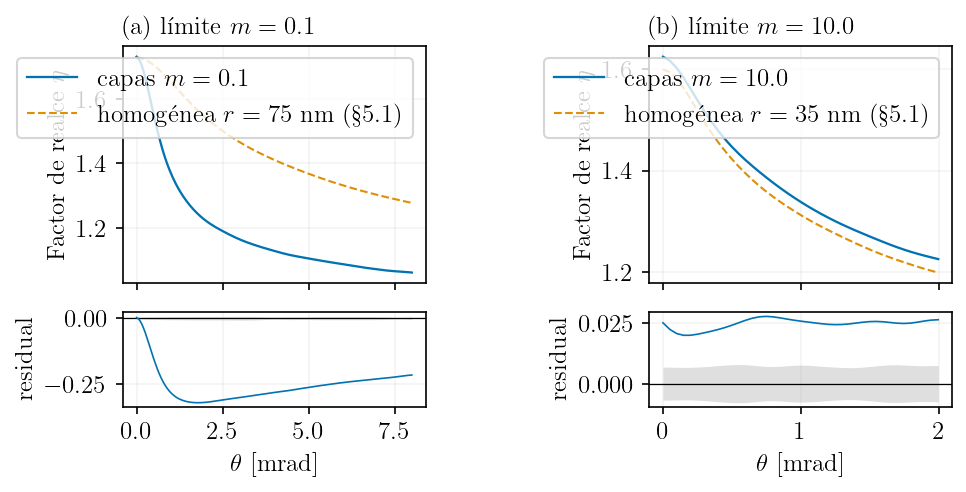

In [8]:
# ===========================================================================
# GATE: m=0.1 vs homogénea r=0.075;  m=10 vs homogénea r=0.035
# ===========================================================================
HOMOG_51 = "study_homog_timeresolved__PLIN__beam2500"
GATES = [(G_BOTLIKE, "radius_0.075", "homogénea $r=75$ nm (§5.1)"),
         (G_TOPLIKE, "radius_0.035", "homogénea $r=35$ nm (§5.1)")]
GATE_THETA_MAX = [8.0, 2.0]      # mrad: cono ancho / cono estrecho

try:
    sweep_h = load_sweep(HOMOG_51, base_path=Path(save_path))
    _have_51 = True
except Exception as err:
    print(f"[gate] §5.1 no disponible: {err}")
    _have_51 = False

if _have_51:
    apply(width_frac=1.0)
    fig, axes = plt.subplots(2, 2, figsize=(TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN), sharex="col",
                             gridspec_kw={"height_ratios": [3, 1.2],
                                          "hspace": 0.08, "wspace": 0.25})
    for col, ((g_mix, sub, lab), thmax) in enumerate(zip(GATES, GATE_THETA_MAX)):
        keys_h = sorted(k_ for k_ in sweep_h.keys() if sub in k_)
        if not keys_h:
            print(f"[gate] no encontré '{sub}' en {HOMOG_51}")
            continue
        g_h = GroupedZ(z=np.nan, mult=np.nan, replicas_keys=keys_h, name=lab)

        # medias por réplica para sigma
        curves_m = [profile_one(key)[1] for key in g_mix.replicas_keys]
        th_m = profile_one(g_mix.replicas_keys[0])[0]
        Em = np.vstack(curves_m).mean(0)
        Sm = np.vstack(curves_m).std(0, ddof=1)

        # referencia homogénea: OJO usa su propio sweep
        curves_h, th_h = [], None
        for key in keys_h:
            sw = sweep_h[key]
            p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=linear,
                              time_index=0, reduce=phi_cut(0))
            p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=linear,
                              time_index=0, reduce=phi_cut(0))
            E1 = (np.asarray(p1.coherent["co"]) + eps) / (np.asarray(p1.incoherent["co"]) + eps)
            E2 = (np.asarray(p2.coherent["co"]) + eps) / (np.asarray(p2.incoherent["co"]) + eps)
            th_h, q_h, Eh = load_stitched(k, L_BOT, np.asarray(p1.theta), E1,
                                          np.asarray(p2.theta), E2, key)
            curves_h.append(Eh - tail_baseline(q_h, Eh) + 1.0)
        Eh = np.vstack(curves_h).mean(0)
        Sh = np.vstack(curves_h).std(0, ddof=1)

        Eh_i = np.interp(th_m, th_h, Eh)
        Sh_i = np.interp(th_m, th_h, Sh)
        n = len(g_mix.replicas_keys)
        sig = np.sqrt(Sm ** 2 + Sh_i ** 2) / np.sqrt(n)
        res = Em - Eh_i

        thm = th_m * 1e3
        m = thm <= thmax
        chi2 = np.mean((res[m] / np.where(sig[m] > 0, sig[m], np.inf)) ** 2)
        rms = np.sqrt(np.mean(res[m] ** 2))

        ax1, ax2 = axes[0, col], axes[1, col]
        ax1.plot(thm[m], Em[m], color=COL[0], lw=1.1,
                 label=rf"capas $m={g_mix.mult:.1f}$")
        ax1.plot(thm[m], Eh_i[m], "--", color=COL[1], lw=1.0, label=lab)
        ax1.set_ylabel(r"Factor de realce $\eta$")
        ax1.grid(alpha=0.15); ax1.legend()
        ax1.set_title(rf"({chr(97+col)}) límite $m={g_mix.mult:.1f}$", loc="left")

        ax2.axhline(0, c="k", lw=0.6)
        ax2.fill_between(thm[m], -2 * sig[m], 2 * sig[m], color="gray",
                         alpha=0.25, lw=0)
        ax2.plot(thm[m], res[m], lw=0.8, color=COL[0])
        ax2.set_xlabel(r"$\theta$ [mrad]"); ax2.set_ylabel("residual")
        ax2.grid(alpha=0.15)

        print(f"[gate m={g_mix.mult:.1f} vs {sub}] chi2/bin = {chi2:.2f}   "
              f"RMS = {rms:.2e}   (theta <= {thmax} mrad, n={n})")
    fig.savefig(FIGDIR / "gate_limites_capas.pdf")
    plt.show()


## F13 — Familia estacionaria: el perfil de dos escalas

Con $\ell^*_{\rm bot} \ll \ell^*_{\rm top}$ el perfil no es un cono de ancho intermedio (eso sería un medio efectivo): es un **cono ancho** (fondo, escala $1/k\ell^*_{\rm bot}$) sobre el que emerge una **espiga estrecha** (top, escala $1/k\ell^*_{\rm top}$) cuyo peso crece con $d$. Panel (a): el cono completo; panel (b): zoom del ápice donde vive la espiga. Este es el argumento visual de que la estratificación **no** admite descripción de medio efectivo.


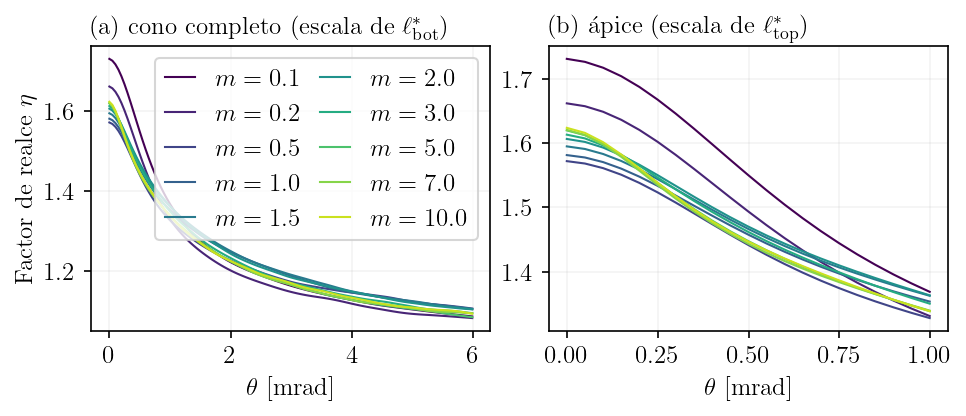

In [14]:
# ===========================================================================
# F13 -- familia gamma(theta; d), realce de intensidades sumadas por réplica
# ===========================================================================
cmap = plt.cm.viridis(np.linspace(0.0, 0.92, len(groups)))
TH_A = 6.0        # mrad: cono completo (escala del BOT)
TH_B = 1.0        # mrad: zoom del ápice (escala del TOP)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))
for c, g in zip(cmap, groups):
    theta, E = profile_mean(g)
    
    thm = theta * 1e3
    for ax, tmax in ((ax1, TH_A), (ax2, TH_B)):
        m = thm <= tmax
        ax.plot(thm[m], E[m], color=c, lw=1.0,
                label=rf"$m={g.mult:.1f}$" if ax is ax1 else None)
ax1.set_xlabel(r"$\theta$ [mrad]"); ax1.set_ylabel(r"Factor de realce $\eta$")
ax1.grid(alpha=0.15); ax1.legend(ncol=2, columnspacing=0.8, handlelength=1.2)
ax1.set_title(r"(a) cono completo (escala de $\ell^*_{\rm bot}$)", loc="left")
ax2.set_xlabel(r"$\theta$ [mrad]")
ax2.grid(alpha=0.15)
ax2.set_title(r"(b) ápice (escala de $\ell^*_{\rm top}$)", loc="left")

fig.savefig(FIGDIR / "F13_familia_espesor.pdf")
plt.show()


## F14 — Observables vs espesor

Tres observables con **profundidades de sondeo distintas**:
- $\theta_{\rm FWHM}(d)$: dominado por transporte profundo; colapsa de la escala del BOT a la del TOP cuando la espiga estrecha supera la media altura — transición abrupta, no gradual (otra firma del perfil de dos escalas).
- $E(0)(d)$ y $\rho(d)=2-E(0)$: la dilución por dispersión simple es un observable de **primer evento** — su profundidad de sondeo es $\sim \ell_s^{\rm top}/2$, distinta de la del ancho. Comparar ambas curvas de saturación es la versión estratificada del par $(\theta_{\rm FWHM},\rho)$ de §5.3.


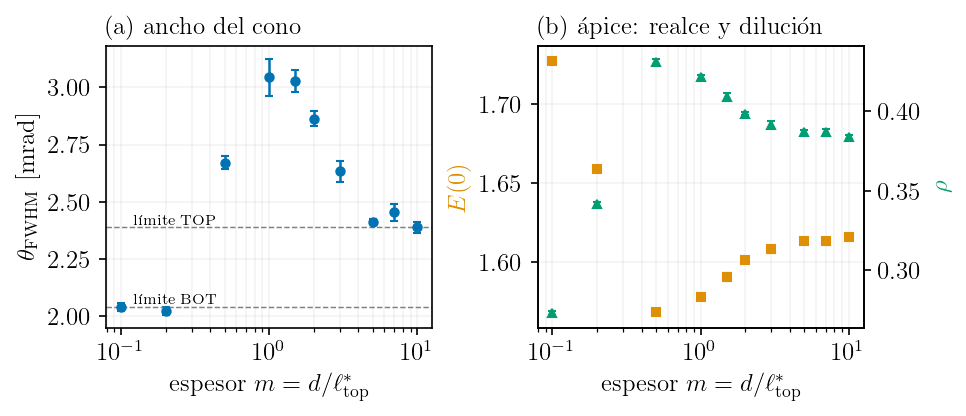

m= 0.10  z=    11.8 um   FWHM= 2.040 mrad   E0=1.7269   rho=0.2731
m= 0.20  z=    23.6 um   FWHM= 2.020 mrad   E0=1.6586   rho=0.3414
m= 0.50  z=    59.0 um   FWHM= 2.671 mrad   E0=1.5689   rho=0.4311
m= 1.00  z=   117.9 um   FWHM= 3.044 mrad   E0=1.5784   rho=0.4216
m= 1.50  z=   176.9 um   FWHM= 3.027 mrad   E0=1.5909   rho=0.4091
m= 2.00  z=   235.9 um   FWHM= 2.863 mrad   E0=1.6014   rho=0.3986
m= 3.00  z=   353.8 um   FWHM= 2.634 mrad   E0=1.6084   rho=0.3916
m= 5.00  z=   589.7 um   FWHM= 2.412 mrad   E0=1.6133   rho=0.3867
m= 7.00  z=   825.6 um   FWHM= 2.453 mrad   E0=1.6133   rho=0.3867
m=10.00  z=  1179.4 um   FWHM= 2.387 mrad   E0=1.6162   rho=0.3838


In [15]:
# ===========================================================================
# F14 -- E0(d), FWHM(d), rho(d) con asintotas de los controles
# ===========================================================================
mults = np.array([g.mult for g in groups])
met = np.array([metric_over_replicas(g) for g in groups])   # E0,sE0,fw,sfw
E0, sE0, FW, sFW = met.T
RHO, sRHO = 2.0 - E0, sE0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN))

ax1.errorbar(mults, FW, sFW, fmt="o", ms=4, capsize=2, color=COL[0], ls="none")
for y, lab in ((FW[0], r"límite BOT ($m\to0$)"), (FW[-1], r"límite TOP ($m\to\infty$)")):
    ax1.axhline(y, ls="--", c="gray", lw=0.7)
ax1.text(0.12, FW[0], r"límite BOT", fontsize=7, va="bottom")
ax1.text(0.12, FW[-1], r"límite TOP", fontsize=7, va="bottom")
ax1.set_xscale("log")
ax1.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax1.set_ylabel(r"$\theta_{\rm FWHM}$ [mrad]")
ax1.grid(alpha=0.15, which="both")
ax1.set_title("(a) ancho del cono", loc="left")

ax2.errorbar(mults, E0, sE0, fmt="s", ms=4, capsize=2, color=COL[1], ls="none",
             label=r"$E(0)$")
ax2b = ax2.twinx()
ax2b.errorbar(mults, RHO, sRHO, fmt="^", ms=4, capsize=2, color=COL[2], ls="none",
              label=r"$\rho = 2-E(0)$")
ax2.set_xscale("log")
ax2.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"$E(0)$", color=COL[1])
ax2b.set_ylabel(r"$\rho$", color=COL[2])
ax2.grid(alpha=0.15, which="both")
ax2.set_title("(b) ápice: realce y dilución", loc="left")

fig.savefig(FIGDIR / "F14_observables_vs_d.pdf")
plt.show()

for g, e0, fw, rho in zip(groups, E0, FW, RHO):
    print(f"m={g.mult:5.2f}  z={g.z:8.1f} um   FWHM={fw:6.3f} mrad   "
          f"E0={e0:.4f}   rho={rho:.4f}")


## F15 — Modelo: medio efectivo vs superposición de dos conos

Dos modelos de un parámetro confrontados con cada perfil:

1. **Cono único** (medio efectivo): $\gamma_d(\theta) = 1 + A\,C(k L_{\rm eff}\theta)$ — debe fallar en el rango intermedio (el perfil tiene dos escalas irreducibles).
2. **Superposición de dos conos** con los perfiles **medidos** de los controles como base:
$\gamma_d - 1 = w(d)\,[\gamma_{\rm top}-1] + (1-w(d))\,[\gamma_{\rm bot}-1]$, un solo parámetro $w$ por espesor (regresión lineal cerrada). Es el análogo estratificado de la Eq. (mix-naive) — y aquí **sí** debe funcionar, porque el medio está segregado: cada tramo de camino vive en una sola especie a la vez y los pesos son las fracciones de retorno desde cada capa.

$w(d)$ se ajusta luego con dos formas de saturación: difusiva de cola pesada $w = m/(m+\zeta)$ y exponencial $w = 1-e^{-m/\zeta}$; la profundidad característica $\zeta$ (en $\ell^*_{\rm top}$) es el número citable.


m= 0.10: cono único L_eff=  18.15 um RMS=2.10e-02   |   dos conos w=0.000±0.012 RMS=0.00e+00
m= 0.20: cono único L_eff=  17.94 um RMS=1.98e-02   |   dos conos w=0.564±0.019 RMS=1.60e-02
m= 0.50: cono único L_eff=  11.98 um RMS=1.99e-02   |   dos conos w=1.199±0.018 RMS=1.04e-02
m= 1.00: cono único L_eff=  11.72 um RMS=1.28e-02   |   dos conos w=1.052±0.026 RMS=1.71e-02
m= 1.50: cono único L_eff=  11.84 um RMS=1.27e-02   |   dos conos w=0.952±0.029 RMS=1.98e-02
m= 2.00: cono único L_eff=  12.42 um RMS=1.37e-02   |   dos conos w=0.892±0.015 RMS=1.65e-02
m= 3.00: cono único L_eff=  13.56 um RMS=1.38e-02   |   dos conos w=0.922±0.020 RMS=6.24e-03
m= 5.00: cono único L_eff=  14.23 um RMS=1.39e-02   |   dos conos w=0.995±0.026 RMS=4.25e-03
m= 7.00: cono único L_eff=  14.03 um RMS=1.48e-02   |   dos conos w=1.019±0.022 RMS=3.53e-03
m=10.00: cono único L_eff=  13.81 um RMS=1.64e-02   |   dos conos w=1.000±0.015 RMS=0.00e+00


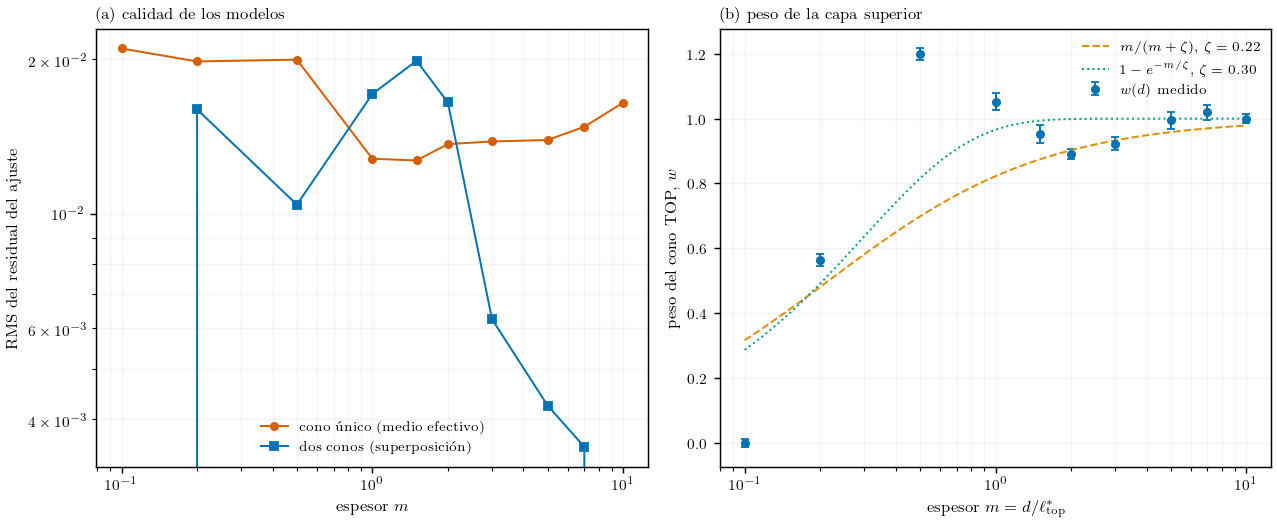

In [8]:
# ===========================================================================
# F15 -- fallo del cono único vs éxito de la superposición de dos conos
# ===========================================================================
from scipy.optimize import curve_fit

B_MILNE = 0.7104
def cone_shape(qq, b=B_MILNE):
    qq = np.maximum(np.asarray(qq, float), 1e-9)
    return (1.0/(1.0 + 2.0*b)) / (1.0 + qq)**2 * (1.0 + (1.0 - np.exp(-2.0*b*qq)) / qq)

# ventana de ajuste: el cono completo del BOT
TH_FIT = 6.0e-3        # rad
th_ref, E_bot = profile_mean(G_BOTLIKE)
_,      E_top = profile_mean(G_TOPLIKE)
mfit = th_ref <= TH_FIT

def fit_single_cone(theta, E):
    model = lambda th, A, L: 1.0 + A * cone_shape(k * L * th)
    p0 = [max(E.max() - 1.0, 0.1), L_BOT]
    popt, _ = curve_fit(model, theta[mfit], E[mfit], p0=p0, maxfev=20000)
    resid = E[mfit] - model(theta[mfit], *popt)
    return popt[0], popt[1], np.sqrt(np.mean(resid ** 2))

def fit_weight(E_d):
    """w cerrado por mínimos cuadrados: (y - fb) = w (ft - fb)."""
    ft, fb, y = E_top - 1.0, E_bot - 1.0, E_d - 1.0
    dd = (ft - fb)[mfit]
    w = float(np.sum((y - fb)[mfit] * dd) / np.sum(dd ** 2))
    resid = (y - fb - w * (ft - fb))[mfit]
    return w, np.sqrt(np.mean(resid ** 2))

rows = []
for g in groups:
    theta, E = profile_mean(g)
    A1, Leff, rms1 = fit_single_cone(theta, E)
    w, rms2 = fit_weight(E)
    # w por réplica -> error estándar
    ws = [fit_weight(profile_one(key)[1])[0] for key in g.replicas_keys]
    rows.append((g.mult, Leff, rms1, w, np.std(ws, ddof=1) / np.sqrt(len(ws)), rms2))
    print(f"m={g.mult:5.2f}: cono único L_eff={Leff:7.2f} um RMS={rms1:.2e}   |   "
          f"dos conos w={w:.3f}±{rows[-1][4]:.3f} RMS={rms2:.2e}")

mults_, Leff_, rms1_, w_, sw_, rms2_ = map(np.array, zip(*rows))

# modelos de saturación de w(d)
w_diff = lambda m_, zeta: m_ / (m_ + zeta)
w_exp  = lambda m_, zeta: 1.0 - np.exp(-m_ / zeta)
z_d, _ = curve_fit(w_diff, mults_, w_, p0=[1.0], sigma=np.maximum(sw_, 1e-3))
z_e, _ = curve_fit(w_exp,  mults_, w_, p0=[1.0], sigma=np.maximum(sw_, 1e-3))
mm = np.geomspace(mults_.min(), mults_.max(), 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTW, 0.42 * TEXTW))

ax1.plot(mults_, rms1_, "o-", ms=4, color=COL[3], label="cono único (medio efectivo)")
ax1.plot(mults_, rms2_, "s-", ms=4, color=COL[0], label="dos conos (superposición)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel(r"espesor $m$"); ax1.set_ylabel("RMS del residual del ajuste")
ax1.grid(alpha=0.15, which="both"); ax1.legend()
ax1.set_title("(a) calidad de los modelos", loc="left")

ax2.errorbar(mults_, w_, sw_, fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
             label=r"$w(d)$ medido")
ax2.plot(mm, w_diff(mm, z_d[0]), "--", color=COL[1],
         label=rf"$m/(m+\zeta)$, $\zeta={z_d[0]:.2f}$")
ax2.plot(mm, w_exp(mm, z_e[0]), ":", color=COL[2],
         label=rf"$1-e^{{-m/\zeta}}$, $\zeta={z_e[0]:.2f}$")
ax2.set_xscale("log")
ax2.set_xlabel(r"espesor $m = d/\ell^*_{\rm top}$")
ax2.set_ylabel(r"peso del cono TOP, $w$")
ax2.grid(alpha=0.15, which="both"); ax2.legend()
ax2.set_title("(b) peso de la capa superior", loc="left")
fig.tight_layout()
fig.savefig(FIGDIR / "F15_modelo_dos_conos.pdf")
plt.show()


## F16 — Time-resolved: $\Delta\theta(t)$ y la interfaz enterrada

Para un medio homogéneo, $\Delta\theta(t)\propto (D t)^{-1/2}$ (recta de pendiente $-1/2$ en log-log, con $D = c\,\ell^*/3n$). En el medio estratificado la luz difunde primero en TOP ($D$ grande, cono estrecho); al alcanzar la interfaz en $t^*\sim \tfrac{3}{2}(d/\ell^*_{\rm top})^2\,\tau^*_{\rm top}$, la dinámica cruza al BOT ($D$ menor) y la curva se **quiebra hacia arriba** respecto de la referencia TOP. Los controles $m=0.1$ y $m=10$ del propio barrido, con la **misma grilla temporal**, sirven de referencias sin interpolación.


m= 0.10: 100 bins temporales válidos
m= 0.20: 100 bins temporales válidos
m= 0.50: 100 bins temporales válidos
m= 1.00: 100 bins temporales válidos
m= 1.50: 100 bins temporales válidos
m= 2.00: 100 bins temporales válidos
m= 3.00: 100 bins temporales válidos
m= 5.00: 100 bins temporales válidos
m= 7.00: 100 bins temporales válidos
m=10.00: 100 bins temporales válidos


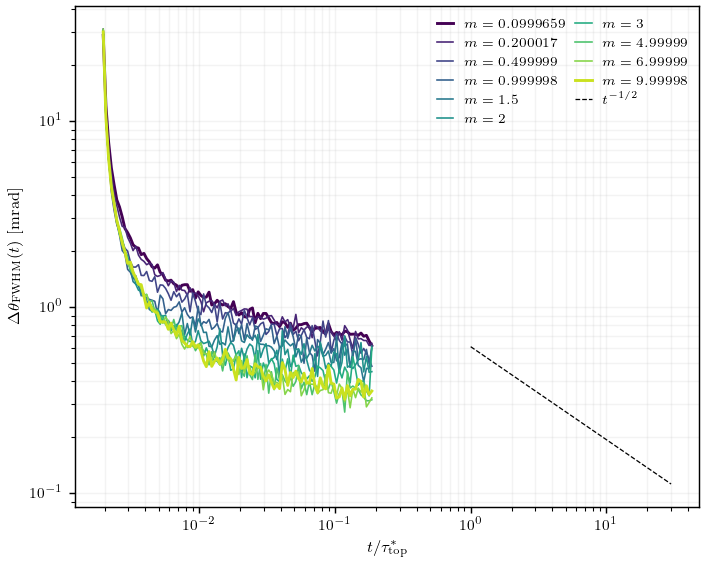

In [10]:
# ===========================================================================
# F16 -- ancho del cono vs tiempo por espesor (intensidades sumadas)
#   Gate de calidad por bin: pico > 5 sigma del ruido de cola y FWHM finito.
# ===========================================================================
TIME_STRIDE = 1                     # sube a 2-3 si tarda demasiado
Z_SELECT = list(range(len(groups))) # subconjunto de espesores a graficar

t_idx = np.arange(1, N_TIME_BINS + 1, TIME_STRIDE)
WIDTHS = {}                          # g.mult -> (t_fs válidos, FWHM mrad)

for gi in Z_SELECT:
    g = groups[gi]
    ts, ws = [], []
    for it in t_idx:
        try:
            theta, E = profile_mean(g, time_index=int(it))
        except Exception:
            continue
        noise = estimate_noise(E)
        e0 = peak_height(E)
        if not np.isfinite(e0) or (e0 - 1.0) < 5 * noise:
            continue
        fw = fwhm_theta(theta, E)
        if not np.isfinite(fw):
            continue
        ts.append(T_FS[it - 1]); ws.append(fw * 1e3)
    WIDTHS[g.mult] = (np.asarray(ts), np.asarray(ws))
    print(f"m={g.mult:5.2f}: {len(ts)} bins temporales válidos")

fig, ax = plt.subplots(figsize=(0.62 * TEXTW, 0.5 * TEXTW))
for c, gi in zip(plt.cm.viridis(np.linspace(0, 0.92, len(Z_SELECT))), Z_SELECT):
    g = groups[gi]
    ts, ws = WIDTHS[g.mult]
    if len(ts) == 0:
        continue
    lw = 1.6 if g in (G_BOTLIKE, G_TOPLIKE) else 0.9
    ax.plot(ts / TAU_TOP_FS, ws, "-", color=c, lw=lw, label=rf"$m={g.mult:g}$")

# guía de pendiente -1/2
tt = np.array([1.0, 30.0])
ts_ref, ws_ref = WIDTHS[G_TOPLIKE.mult]
if len(ts_ref):
    w_anchor = np.interp(3.0 * TAU_TOP_FS, ts_ref, ws_ref)
    ax.plot(tt, w_anchor * (tt / 3.0) ** (-0.5), "k--", lw=0.7,
            label=r"$t^{-1/2}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$t / \tau^*_{\rm top}$")
ax.set_ylabel(r"$\Delta\theta_{\rm FWHM}(t)$ [mrad]")
ax.grid(alpha=0.15, which="both")
ax.legend(ncol=2, columnspacing=0.8, handlelength=1.2)
fig.savefig(FIGDIR / "F16_ancho_vs_t.pdf")
plt.show()


## F17 — Escalamiento difusivo $t^*\propto d^2$

Extracción del tiempo de quiebre: cociente $R_d(t) = \Delta\theta_d(t)/\Delta\theta_{\rm top}(t)$ contra la referencia TOP (misma grilla, cociente bin a bin). $R$ parte de 1 y sube hacia el contraste asintótico cuando los fotones alcanzan el fondo; $t^*$ = primer cruce del punto medio geométrico. La predicción difusiva es $t^* = \alpha\, m^2\,\tau^*_{\rm top}$ con $\alpha\sim\mathcal{O}(1)$: recta de pendiente 1 en log-log vs $m^2$. Solo participan los espesores con interfaz alcanzable ($\tfrac32 m^2 < M_{\rm top}$).


m= 0.10: R_tardio=1.94  t* = 0.00 tau*_top
m= 0.20: R_tardio=1.86  t* = 0.00 tau*_top
m= 0.50: R_tardio=1.72  t* = 0.00 tau*_top
m= 1.00: R_tardio=1.56  t* = 0.01 tau*_top
m= 1.50: R_tardio=1.44  t* = 0.01 tau*_top
m= 2.00: R_tardio=1.36  t* = 0.01 tau*_top
m= 3.00: R_tardio=1.18  t* = 0.02 tau*_top
m= 5.00: R_tardio=0.99 -> sin quiebre resoluble
m= 7.00: R_tardio=0.94 -> sin quiebre resoluble


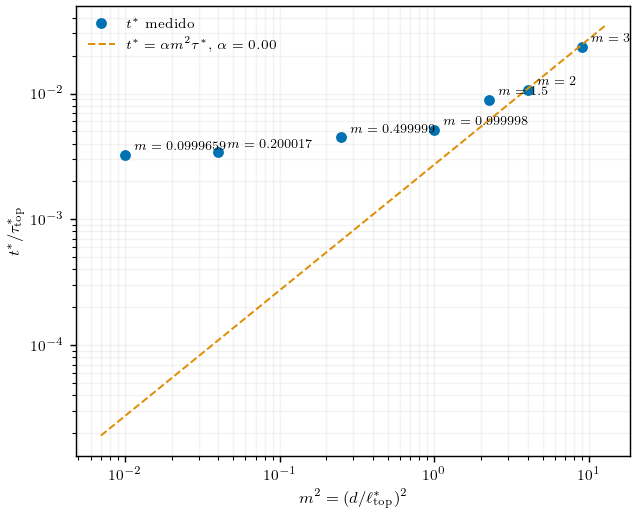


alpha ajustado = 0.00   (estimación difusiva ~ 3/2)


In [11]:
# ===========================================================================
# F17 -- t*(d) del cociente contra la referencia TOP; ajuste t* = alpha m^2 tau*
# ===========================================================================
ts_ref, ws_ref = WIDTHS[G_TOPLIKE.mult]

tstars, mstars = [], []
for g in groups[:-1]:                       # excluye la propia referencia
    ts, ws = WIDTHS[g.mult]
    if len(ts) < 8 or len(ts_ref) < 8:
        continue
    # malla común (bins válidos en ambos)
    t_lo, t_hi = max(ts.min(), ts_ref.min()), min(ts.max(), ts_ref.max())
    m = (ts >= t_lo) & (ts <= t_hi)
    R = ws[m] / np.interp(ts[m], ts_ref, ws_ref)
    tR = ts[m]
    if len(R) < 8:
        continue
    R_late = np.median(R[-max(3, len(R)//5):])
    if R_late < 1.15:                        # sin contraste: no hay quiebre medible
        print(f"m={g.mult:5.2f}: R_tardio={R_late:.2f} -> sin quiebre resoluble")
        continue
    thr = np.sqrt(R_late)                    # punto medio geométrico entre 1 y R_late
    above = (R > thr) & (np.roll(R, -1) > thr)   # cruce persistente (2 bins)
    idx = np.where(above)[0]
    if len(idx) == 0:
        continue
    tstars.append(tR[idx[0]] / TAU_TOP_FS)
    mstars.append(g.mult)
    print(f"m={g.mult:5.2f}: R_tardio={R_late:.2f}  t* = {tstars[-1]:.2f} tau*_top")

tstars, mstars = np.asarray(tstars), np.asarray(mstars)

fig, ax = plt.subplots(figsize=(0.55 * TEXTW, 0.45 * TEXTW))
if len(tstars) >= 2:
    u = mstars ** 2
    alpha = np.sum(u * tstars) / np.sum(u ** 2)     # recta por el origen
    uu = np.geomspace(u.min() * 0.7, u.max() * 1.4, 50)
    ax.plot(u, tstars, "o", ms=5, color=COL[0], label=r"$t^*$ medido")
    ax.plot(uu, alpha * uu, "--", color=COL[1],
            label=rf"$t^*=\alpha m^2\tau^*$, $\alpha={alpha:.2f}$")
    for mi, ui, ti in zip(mstars, u, tstars):
        ax.annotate(rf"$m={mi:g}$", (ui, ti), textcoords="offset points",
                    xytext=(5, 3), fontsize=7)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel(r"$m^2 = (d/\ell^*_{\rm top})^2$")
    ax.set_ylabel(r"$t^* / \tau^*_{\rm top}$")
    ax.grid(alpha=0.15, which="both"); ax.legend()
    fig.savefig(FIGDIR / "F17_tstar_vs_d2.pdf")
    plt.show()
    print(f"\nalpha ajustado = {alpha:.2f}   (estimación difusiva ~ 3/2)")
else:
    print("insuficientes t* para el ajuste: revisa el gate de calidad de F16")


## Tabla resumen

$(z, m, \theta_{\rm FWHM}, E_0, \rho, L_{\rm eff}, w, t^*)$ → CSV + filas LaTeX.


In [12]:
# ===========================================================================
# Tabla resumen -> CSV + LaTeX
# ===========================================================================
tst_map = dict(zip(mstars, tstars)) if len(tstars) else {}
rows_t = []
for i, g in enumerate(groups):
    rows_t.append({
        "z_um": g.z, "mult": g.mult,
        "FWHM_mrad": FW[i], "s_FWHM": sFW[i],
        "E0": E0[i], "s_E0": sE0[i],
        "rho": RHO[i], "s_rho": sRHO[i],
        "L_eff_um": Leff_[i], "w_top": w_[i], "s_w": sw_[i],
        "tstar_taustar": tst_map.get(g.mult, np.nan),
    })
df_cap = pd.DataFrame(rows_t)
df_cap.to_csv(FIGDIR / "tabla_capas.csv", index=False)
display(df_cap.round(4))

def pm(v, s, nd=3):
    return rf"${v:.{nd}f} \pm {s:.{nd}f}$"

lines = []
for _, r in df_cap.iterrows():
    ts_txt = f"{r['tstar_taustar']:.2f}" if np.isfinite(r["tstar_taustar"]) else "--"
    lines.append("    " + " & ".join([
        f"{r['mult']:g}", f"{r['z_um']:.0f}",
        pm(r["FWHM_mrad"], r["s_FWHM"], 3),
        pm(r["E0"], r["s_E0"]),
        pm(r["w_top"], r["s_w"]),
        ts_txt,
    ]) + r" \\")
tex = "\n".join(lines)
(FIGDIR / "tabla_capas.tex").write_text(tex)
print(tex)
print(f"\nguardado: {FIGDIR/'tabla_capas.csv'} y {FIGDIR/'tabla_capas.tex'}")


,z_um,mult,FWHM_mrad,s_FWHM,E0,s_E0,rho,s_rho,L_eff_um,w_top,s_w,tstar_taustar
0,11.79,0.1,2.0398,0.0170,1.7269,0.0014,0.2731,0.0014,18.1497,0.0000,0.0124,0.0032
1,23.59,0.2,2.0200,0.0170,1.6586,0.0015,0.3414,0.0015,17.9402,0.5642,0.0189,0.0034
2,58.97,0.5,2.6709,0.0299,1.5689,0.0020,0.4311,0.0020,11.9810,1.1985,0.0179,0.0045
3,117.94,1.0,3.0436,0.0821,1.5784,0.0014,0.4216,0.0014,11.7227,1.0525,0.0260,0.0051
4,176.91,1.5,3.0274,0.0470,1.5909,0.0026,0.4091,0.0026,11.8406,0.9524,0.0289,0.0089
5,235.88,2.0,2.8634,0.0313,1.6014,0.0012,0.3986,0.0012,12.4222,0.8916,0.0153,0.0107
6,353.82,3.0,2.6335,0.0461,1.6084,0.0022,0.3916,0.0022,13.5592,0.9223,0.0199,0.0235
7,589.70,5.0,2.4122,0.0122,1.6133,0.0018,0.3867,0.0018,14.2272,0.9949,0.0258,NaN
8,825.58,7.0,2.4532,0.0369,1.6133,0.0021,0.3867,0.0021,14.0318,1.0191,0.0223,NaN
9,1179.40,10.0,2.3866,0.0254,1.6162,0.0013,0.3838,0.0013,13.8104,1.0000,0.0146,NaN


    0.0999659 & 12 & $2.040 \pm 0.017$ & $1.727 \pm 0.001$ & $0.000 \pm 0.012$ & 0.00 \\
    0.200017 & 24 & $2.020 \pm 0.017$ & $1.659 \pm 0.002$ & $0.564 \pm 0.019$ & 0.00 \\
    0.499999 & 59 & $2.671 \pm 0.030$ & $1.569 \pm 0.002$ & $1.199 \pm 0.018$ & 0.00 \\
    0.999998 & 118 & $3.044 \pm 0.082$ & $1.578 \pm 0.001$ & $1.052 \pm 0.026$ & 0.01 \\
    1.5 & 177 & $3.027 \pm 0.047$ & $1.591 \pm 0.003$ & $0.952 \pm 0.029$ & 0.01 \\
    2 & 236 & $2.863 \pm 0.031$ & $1.601 \pm 0.001$ & $0.892 \pm 0.015$ & 0.01 \\
    3 & 354 & $2.634 \pm 0.046$ & $1.608 \pm 0.002$ & $0.922 \pm 0.020$ & 0.02 \\
    4.99999 & 590 & $2.412 \pm 0.012$ & $1.613 \pm 0.002$ & $0.995 \pm 0.026$ & -- \\
    6.99999 & 826 & $2.453 \pm 0.037$ & $1.613 \pm 0.002$ & $1.019 \pm 0.022$ & -- \\
    9.99998 & 1179 & $2.387 \pm 0.025$ & $1.616 \pm 0.001$ & $1.000 \pm 0.015$ & -- \\

guardado: figs_tesis/tabla_capas.csv y figs_tesis/tabla_capas.tex
